# Plot Forcing versus Delta

Import Statements

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## List data

In [2]:
start = 2004
stop = 2023

# path
path = "/glade/work/smhenry/NeuralGCM/data/ERA5/"

# name
name_list_forcing_cf = [
    path + f"ERA5_forcing_{yr}_JASO_counterfactual.nc" for yr in range(start, stop + 1)
]
name_list_forcing_f = [
    path + f"ERA5_forcing_{yr}_JASO.nc" for yr in range(start, stop + 1)
]

In [3]:
name_dSST = "/glade/work/mingshiy/_GPU_work/NeuralGCM/data/tos_Omon_delta_Nat-Hist_CMIP5-est1_v1-0_period199001-203012_199001-203012.nc"  # Mingshi's directory
df_dSST = xr.open_dataset(name_dSST).rename({"lon": "longitude", "lat": "latitude"})

In [4]:
start_hist = 1940
stop_hist = 2003

path_hist = "/glade/derecho/scratch/smhenry/neuralGCM/Data/ERA5/"

name_list_forcing_hist = [
    path_hist + f"ERA5_forcing_{yr}_JASO.nc" for yr in range(start_hist, stop_hist + 1)
]

## Process forcing and delta data

### SST

In [5]:
# open delta data
yr_dSST = []
for yr in range(start, stop + 1):
    yr_dat = (
        (
            xr.open_dataset(name_list_forcing_f[yr - start]).sea_surface_temperature
            - xr.open_dataset(name_list_forcing_cf[yr - start]).sea_surface_temperature
        )
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SST [K]")
    )
    yr_dSST.append(yr_dat)

mean_dSST = xr.concat(yr_dSST, dim="year").mean(dim="year").sel(latitude=slice(-50, 50))

mean_dSST = mean_dSST.assign_coords(longitude=(((mean_dSST.longitude + 180) % 360) - 180))
mean_dSST = mean_dSST.sortby("longitude")

In [6]:
# open factual data
yr_SST_f = []
for yr in range(start, stop + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_f[yr - start]).sea_surface_temperature)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SST [K]")
    )
    yr_SST_f.append(yr_dat)


# open counterfactual data
yr_SST_cf = []
for yr in range(start, stop + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_cf[yr - start]).sea_surface_temperature)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SST [K]")
    )
    yr_SST_cf.append(yr_dat)

# open hist data
yr_SST_hist = []
for yr in range(start_hist, stop_hist + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_hist[yr - start_hist]).sea_surface_temperature)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SST [K]")
    )
    yr_SST_hist.append(yr_dat)

In [7]:
tseries_SST_f = xr.concat(yr_SST_f, dim="year").sel(latitude=slice(-30,30)).mean(dim=["latitude","longitude"])
tseries_SST_cf = xr.concat(yr_SST_cf, dim="year").sel(latitude=slice(-30,30)).mean(dim=["latitude","longitude"])
tseries_SST_hist = xr.concat(yr_SST_hist, dim="year").sel(latitude=slice(-30,30)).mean(dim=["latitude","longitude"])

yr_SST_hist_P1 = xr.concat(yr_SST_hist, dim="year").sel(year=slice(1949,1985)).mean(dim="year")
yr_SST_hist_P2 = xr.concat(yr_SST_hist, dim="year").sel(year=slice(1987,2023)).mean(dim="year")
mean_SST_hist_P2mP1 = yr_SST_hist_P2 - yr_SST_hist_P1

mean_SST_hist_P2mP1 = mean_SST_hist_P2mP1.assign_coords(longitude=(((mean_SST_hist_P2mP1.longitude + 180) % 360) - 180))
mean_SST_hist_P2mP1 = mean_SST_hist_P2mP1.sortby("longitude")

### SIC

In [21]:
# open data
yr_dSIC = []
for yr in range(start, stop + 1):
    yr_dat = (
        (
            xr.open_dataset(name_list_forcing_f[yr - start]).sea_ice_cover
            - xr.open_dataset(name_list_forcing_cf[yr - start]).sea_ice_cover
        )
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SIC [fraction]")
    )
    yr_dSIC.append(yr_dat)


mean_dSIC = xr.concat(yr_dSIC, dim="year").mean(dim="year")

mean_dSIC = mean_dSIC.assign_coords(longitude=(((mean_dSIC.longitude + 180) % 360) - 180))
mean_dSIC = mean_dSIC.sortby("longitude")

In [22]:
# open factual data
yr_SIC_f = []
for yr in range(start, stop + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_f[yr - start]).sea_ice_cover)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SIC [fraction]")
    )
    yr_SIC_f.append(yr_dat)


# open counterfactual data
yr_SIC_cf = []
for yr in range(start, stop + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_cf[yr - start]).sea_ice_cover)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SIC [fraction]")
    )
    yr_SIC_cf.append(yr_dat)

# open hist data
yr_SIC_hist = []
for yr in range(start_hist, stop_hist + 1):
    yr_dat = (
        (xr.open_dataset(name_list_forcing_hist[yr - start_hist]).sea_ice_cover)
        .mean(dim="time")
        .assign_coords({"year": yr})
        .rename("SIC [fraction]")
    )
    yr_SIC_hist.append(yr_dat)

In [23]:
tseries_SIC_f_NH = xr.concat(yr_SIC_f, dim="year").sel(latitude=slice(-90,-45)).mean(dim=["latitude","longitude"])
tseries_SIC_cf_NH = xr.concat(yr_SIC_cf, dim="year").sel(latitude=slice(-90,-45)).mean(dim=["latitude","longitude"])
tseries_SIC_hist_NH = xr.concat(yr_SIC_hist, dim="year").sel(latitude=slice(-90,-45)).mean(dim=["latitude","longitude"])

tseries_SIC_f_SH = xr.concat(yr_SIC_f, dim="year").sel(latitude=slice(45,90)).mean(dim=["latitude","longitude"])
tseries_SIC_cf_SH = xr.concat(yr_SIC_cf, dim="year").sel(latitude=slice(45,90)).mean(dim=["latitude","longitude"])
tseries_SIC_hist_SH = xr.concat(yr_SIC_hist, dim="year").sel(latitude=slice(45,90)).mean(dim=["latitude","longitude"])

## Plot delta data

In [24]:
# fig, axs = plt.subplots(
#     nrows=2,
#     figsize=(10, 8),
#     subplot_kw={"projection": ccrs.PlateCarree()},
#     constrained_layout=True,
#     gridspec_kw={"height_ratios": [1, 2]},
# )

# # Plot dSST (top, smaller)
# mean_dSST.plot.contourf(
#     x="longitude",
#     y="latitude",
#     robust=True,
#     ax=axs[0],
#     transform=ccrs.PlateCarree(),
#     extend="both",
#     cmap="turbo",
#     levels=np.arange(0, 1 + 0.1, 0.1),
# )
# axs[0].add_feature(cfeature.LAND, edgecolor='black', facecolor='black', zorder=10)

# axs[0].coastlines()
# gl = axs[0].gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
# gl.top_labels = False
# gl.right_labels = False
# gl.bottom_labels = False
# axs[0].set_title(f"(a) {start}-{stop} Mean (Factual - Counterfactual) SST Forcing", fontsize=14)

# # Plot dSIC (bottom, taller)
# mean_dSIC.plot.contourf(
#     x="longitude",
#     y="latitude",
#     robust=True,
#     ax=axs[1],
#     transform=ccrs.PlateCarree(),
#     extend="min",
#     cmap="Greens_r",
#     levels=np.arange(-1, 0.1, 0.1),
#     cbar_kwargs={
#         "shrink": 0.7,     # shrink colorbar to 70% of default length
#         "aspect": 30       # adjust thickness/length ratio
#     },
# )
# # axs[1].add_feature(cfeature.LAND, edgecolor="white", facecolor="white", zorder=10, alpha=0.5)

# axs[1].coastlines()
# gl = axs[1].gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
# gl.top_labels = False
# gl.right_labels = False
# gl.bottom_labels = True
# axs[1].set_title(f"(b) {start}-{stop} Mean (Factual - Counterfactual) SIC Forcing", fontsize=14)

# # Save combined figure
# save = True
# if save:
#     plt.savefig(
#         f"./figs/SI_figure_dSST_dSIC_factual-counterfactual.png",
#         dpi=300,
#         bbox_inches="tight",
#     )

# plt.show()

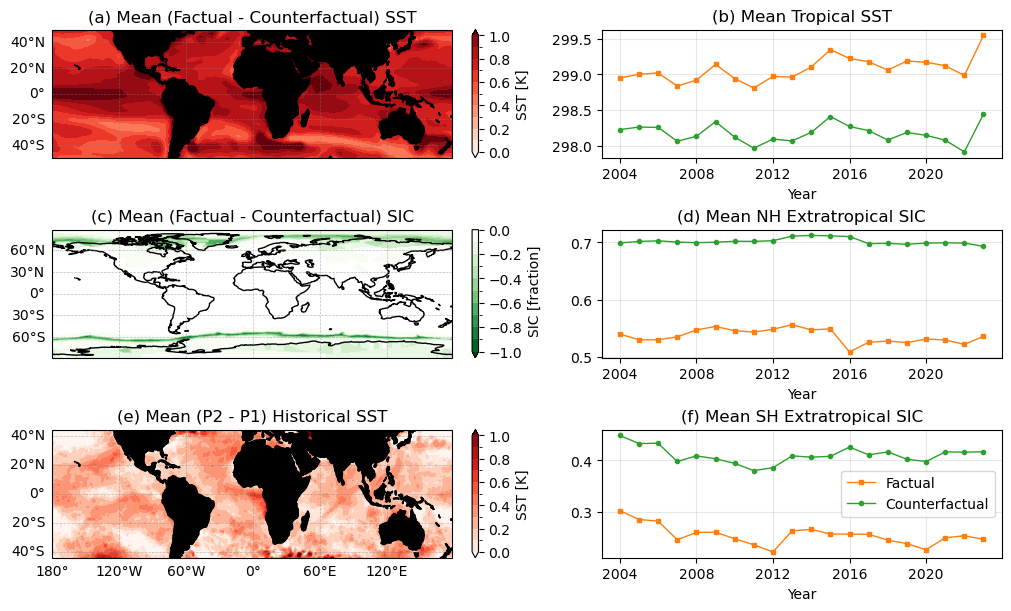

In [25]:
yrlist = np.arange(start, stop + 1)
fig = plt.figure(figsize=(10, 6), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=2)
# Left column: map axes (with projection)
ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())  # dSST
ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())  # dSIC
ax4 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree())  # hist SST
# Right column: timeseries axes (plain, no projection)
ax1 = fig.add_subplot(gs[0, 1])  # SST timeseries
ax3 = fig.add_subplot(gs[1, 1])  # SIC timeseries
ax5 = fig.add_subplot(gs[2, 1])  # legend panel

# Plot dSST (row 0, left)
mean_dSST.plot.contourf(
    x="longitude", y="latitude", robust=True, ax=ax0,
    transform=ccrs.PlateCarree(), extend="both", cmap="Reds",
    levels=np.arange(0, 1 + 0.1, 0.1),
)
ax0.set_aspect("auto")
ax0.add_feature(cfeature.LAND, edgecolor='black', facecolor='black', zorder=10)
ax0.coastlines()
gl = ax0.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
ax0.set_title(f"(a) Mean (Factual - Counterfactual) SST", fontsize=12)

# SST timeseries (row 0, right)
l1, = ax1.plot(yrlist, tseries_SST_f, color="tab:orange", label="Factual", linewidth=1, marker="s", markersize=3)
l2, = ax1.plot(yrlist, tseries_SST_cf, color="tab:green", label="Counterfactual", linewidth=1, marker="o", markersize=3)
ax1.set_xlabel("Year", fontsize=10)
ax1.set_xticks(np.arange(start, stop + 1, 4))
ax1.set_title(f"(b) Mean Tropical SST", fontsize=12)
ax1.tick_params(axis="both", which="major", labelsize=10)
ax1.grid(alpha=0.3)

# Plot dSIC (row 1, left)
mean_dSIC.plot.contourf(
    x="longitude", y="latitude", robust=True, ax=ax2,
    transform=ccrs.PlateCarree(), extend="min", cmap="Greens_r",
    levels=np.arange(-1, 0.1, 0.1),
    cbar_kwargs={"shrink": 1, "aspect": 20},
)
ax2.set_aspect("auto")
ax2.coastlines()
gl = ax2.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
ax2.set_title(f"(c) Mean (Factual - Counterfactual) SIC", fontsize=12)

# SIC timeseries (row 1, right)
ax3.plot(yrlist, tseries_SIC_f_NH, color="tab:orange", label="Factual", linewidth=1, marker="s", markersize=3)
ax3.plot(yrlist, tseries_SIC_cf_NH, color="tab:green", label="Counterfactual", linewidth=1, marker="o", markersize=3)
ax3.set_xlabel("Year", fontsize=10)
ax3.set_xticks(np.arange(start, stop + 1, 4))
ax3.set_title(f"(d) Mean NH Extratropical SIC", fontsize=12)
ax3.tick_params(axis="both", which="major", labelsize=10)
ax3.grid(alpha=0.3)

# Plot hist SST (row 2, left)
mean_SST_hist_P2mP1.sel(latitude=slice(-45, 45)).plot.contourf(
    x="longitude", y="latitude", robust=True, ax=ax4,
    transform=ccrs.PlateCarree(), extend="both", cmap="Reds",
    levels=np.arange(0, 1 + 0.1, 0.1),
)
ax4.set_aspect("auto")
ax4.add_feature(cfeature.LAND, edgecolor='black', facecolor='black', zorder=10)
ax4.coastlines()
gl = ax4.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
ax4.set_title(f"(e) Mean (P2 - P1) Historical SST", fontsize=12)

# Legend panel (row 2, right)
ax5.plot(yrlist, tseries_SIC_f_SH, color="tab:orange", label="Factual", linewidth=1, marker="s", markersize=3)
ax5.plot(yrlist, tseries_SIC_cf_SH, color="tab:green", label="Counterfactual", linewidth=1, marker="o", markersize=3)
ax5.set_xlabel("Year", fontsize=10)
ax5.set_xticks(np.arange(start, stop + 1, 4))
ax5.set_title(f"(f) Mean SH Extratropical SIC", fontsize=12)
ax5.tick_params(axis="both", which="major", labelsize=10)
ax5.grid(alpha=0.3)
ax5.legend()

# Save
save = True
if save:
    plt.savefig(
        f"./figs/SI_figure_dSST_dSIC_factual-counterfactual.png",
        dpi=300,
        bbox_inches="tight",
    )
plt.show()